# Lakeside heating DSM — human source of truth

**This notebook is the human-facing proof that the shipped model works.**

Run top-to-bottom after a native EnergyPlus farm. It must show, in one place:

1. **Provenance** — `ENERGYPLUS_NATIVE_RUN` only (Ideal Loads + fixed-COP proxy — not a GSHP plant)
2. **IDF / EPW hashes** and Guideline 14 monthly status (separate from interval demand)
3. **Measured vs modeled** overlay + MAE / **RMSE** / bias (kW)
4. **Sklearn bake-off** → champion → desktop ONNX ship path
5. **Recursive 24h walk** metrics (deployment mode — not teacher-forced)

| | |
|---|---|
| **Desktop target** | `facility_kw` only (single-output) |
| **Training labels** | Native E+ timestep meters → IdealLoads+COP site kW |
| **Desktop artifact** | `ml/artifacts/heating_dsm_hourly_v1.onnx` + `_feature_meta.json` |
| **Honesty** | Ideal Loads + COP proxy · **CANDIDATE** · zero-severe native runs only |

Multi-output zone temps remain a **DEMO** section at the bottom — not desktop.


## 0 · Setup


## Human scoreboard — provenance + measured vs modeled

**Read this section first.** It fails loud if the farm is still a proxy stamp or MVM artifacts are missing.


In [ ]:
import os
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

SITE = Path(os.environ.get("LAKESIDE_SITE_ROOT", r"C:\Users\ben\OneDrive\Desktop\testing\sp_creekside"))
farm_sum = PATHS.get("eplus_farm") and (PATHS["eplus_farm"].parent / "eplus_farm_summary.json")
if not farm_sum or not Path(farm_sum).is_file():
    farm_sum = ROOT / "ml" / "artifacts" / "eplus_farm_summary.json"
elig = SITE / "eplus" / "models" / "staged" / "DSM_ELIGIBLE.json"
mvm = SITE / "reports" / "eplus" / "mvm" / "mvm_summary.json"
mvm_png = SITE / "reports" / "eplus" / "mvm" / "mvm_hourly_overlay.png"
mvm_parity = SITE / "reports" / "eplus" / "mvm" / "mvm_parity.png"
mvm_gl14 = SITE / "reports" / "eplus" / "mvm" / "mvm_monthly_gl14.png"

assert Path(farm_sum).is_file(), "Run scripts/eplus_heating_dsm_farm.py first"
fs = json.loads(Path(farm_sum).read_text(encoding="utf-8"))
assert fs.get("provenance") == "ENERGYPLUS_NATIVE_RUN", fs
assert elig.is_file(), "Run scripts/eplus_stage_repair_and_rescore.py first"
ej = json.loads(elig.read_text(encoding="utf-8"))

lines = [
    "### Native EnergyPlus gate — PASSED",
    f"- **Provenance:** `{fs['provenance']}`",
    f"- **Accepted scenarios:** {fs.get('n_scenarios_accepted')} · rows={fs.get('n_rows')}",
    f"- **Staged IDF SHA-256:** `{ej.get('staged_sha256')}`",
    f"- **EPW SHA-256:** `{fs.get('epw_sha256')}`",
    f"- **Monthly utility GL14:** `{ej.get('gl14_status')}` · NMBE={ej.get('nmbe_pct')}% · CVRMSE={ej.get('cvrmse_pct')}%",
    f"- **Honesty:** {fs.get('honesty')}",
]
if mvm.is_file():
    ms = json.loads(mvm.read_text(encoding="utf-8"))
    lines += [
        "",
        "### Interval demand validation (separate from monthly GL14)",
        f"- **n hourly:** {ms.get('n_hourly')}",
        f"- **MAE:** {ms.get('hourly_mae_kw'):.2f} kW",
        f"- **RMSE:** {ms.get('hourly_rmse_kw'):.2f} kW",
        f"- **MBE / NMBE:** {ms.get('hourly_mbe_kw'):.2f} kW / {ms.get('hourly_nmbe_pct'):.2f}%",
        f"- **CVRMSE:** {ms.get('hourly_cvrmse_pct'):.2f}% (denom={ms.get('cvrmse_denominator')})",
    ]
else:
    lines.append("\n_MVM summary missing — run `python -u scripts/validate_mvm.py`_")

display(Markdown("\n".join(lines)))

figs = [p for p in (mvm_png, mvm_parity, mvm_gl14) if p.is_file()]
if figs:
    fig, axes = plt.subplots(1, len(figs), figsize=(5 * len(figs), 4))
    if len(figs) == 1:
        axes = [axes]
    for ax, p in zip(axes, figs):
        ax.imshow(plt.imread(p))
        ax.set_title(p.name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("MVM plots not found yet — run validate_mvm.py")


In [ ]:
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import GroupKFold
from sklearn.base import clone

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path(".").resolve()
ML = ROOT / "ml"
sys.path.insert(0, str(ML))

from artifact_paths import artifact_paths, train_parquet_path
from feature_compile_heating_dsm import (
    FEATURE_COLS, compile_features, matrix_xy, morning_peak_mask,
    assert_no_future_leakage, cost_from_hourly_kw,
)
from train_heating_dsm import bake_off
from export_sklearn_onnx import ship_desktop_champion, DISPLAY_NAMES
from notebook_plots import (
    family_cv_mae_bars, family_mae_rmse_grouped, leaderboard_table,
    oat_vs_kw_scatter, strategy_morning_peak_bars, example_day_profiles,
    residual_hist, pred_vs_actual, feature_importance_bar,
    explainer_vs_target_grid, lag_dependence_panel, metrics_scorecard,
    feature_target_catalogs, save_fig,
)

PATHS = artifact_paths()
PATHS["figures"].mkdir(parents=True, exist_ok=True)
print("ROOT", ROOT)
print("features", len(FEATURE_COLS))


## 1 · Explainer features & prediction target

Lag columns are marked **explainer (LAG)** — same-calendar-day only (no future leakage).


In [11]:
feat_cat, tgt_cat = feature_target_catalogs()
print(f"{len(feat_cat)} explainer features · {len(tgt_cat)} target(s)")
display(feat_cat)
display(tgt_cat)
lag_rows = feat_cat[feat_cat["role"].str.contains("LAG")]
print("LAG features in the matrix:")
display(lag_rows)


39 explainer features · 1 target(s)


,feature,role,description
0,hour_ending,explainer,Hour-ending clock (0–23 local)
1,sin_hour,explainer,Cyclical hour (sin)
2,cos_hour,explainer,Cyclical hour (cos)
3,month,explainer,Calendar month
4,doy,explainer,Day of year
5,is_weekend,explainer,Weekend flag (0/1)
6,occupied,explainer,Occupied flag (generic K12 07–16)
7,oat_f,explainer,Outdoor air temperature °F
8,oat_lag1,explainer (LAG),Prior-hour OAT °F (LAG — no future leak)
9,hdd65,explainer,Heating degree hours base 65°F


,target,role,description
0,facility_kw,prediction,Whole-building electric demand [kW] — primary ...


LAG features in the matrix:


,feature,role,description
8,oat_lag1,explainer (LAG),Prior-hour OAT °F (LAG — no future leak)
32,facility_kw_lag1,explainer (LAG),Prior-hour facility kW (LAG — no future leak)
33,facility_kw_lag2,explainer (LAG),Two-hour lag facility kW (LAG)


## 2 · Load train parquet (E+ farm preferred)


In [12]:
import subprocess
pq = train_parquet_path()
if not pq.is_file():
    farm_script = ROOT / "scripts" / "eplus_heating_dsm_farm.py"
    if farm_script.is_file():
        subprocess.check_call([sys.executable, "-u", str(farm_script)], cwd=str(ROOT))
        pq = train_parquet_path()
    if not pq.is_file():
        subprocess.check_call([sys.executable, "-u", str(ML / "build_bootstrap_dataset.py")], cwd=str(ROOT))
        pq = train_parquet_path()
df = pd.read_parquet(pq)
src = str(df["provenance"].iloc[0]) if "provenance" in df.columns and len(df) else "unknown"
print("parquet", pq)
print("provenance", src, "shape", df.shape)
print(df["strategy_id"].value_counts())
df.head(3)


parquet C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\heating_dsm_eplus_farm_hourly.parquet
provenance ENERGYPLUS_SIMULATED shape (2880, 33)
strategy_id
baseline           576
stagger_preheat    576
flat_24_7          576
deep_setback       576
morning_all_on     576
Name: count, dtype: int64


,day,simulation_id,hour_ending,month,doy,is_weekend,occupied,oat_f,rh_pct,ghi,...,occ_frac_2F_B,hp_on_1F_A,hp_on_1F_B,hp_on_1F_C,hp_on_1F_D,hp_on_2F_A,hp_on_2F_B,twin_idf,heat_cop_proxy,schema_version
0,2026-01-23,2026-01-23__baseline,0,1,23,0.0,0.0,-5.641667,59.375000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,lakeside_6zone_gshp_best.idf,3.5,lakeside.heating_dsm_farm.v1
1,2026-01-23,2026-01-23__baseline,1,1,23,0.0,0.0,-7.775000,58.708333,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,lakeside_6zone_gshp_best.idf,3.5,lakeside.heating_dsm_farm.v1
2,2026-01-23,2026-01-23__baseline,2,1,23,0.0,0.0,-10.500000,52.791667,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,lakeside_6zone_gshp_best.idf,3.5,lakeside.heating_dsm_farm.v1


## 3 · Feature compile + leakage guard


In [13]:
feat = compile_features(df)
assert_no_future_leakage(df)
X, y, groups, cols = matrix_xy(df)
peak = morning_peak_mask(df)
print("X", X.shape, "peak hours", int(peak.sum()), "days", pd.Series(groups).nunique())
feat[FEATURE_COLS].describe().T.head(12)


X (2880, 39) peak hours 600 days 24


,count,mean,std,min,25%,50%,75%,max
hour_ending,2880.0,1.150000e+01,6.923389,0.000000,5.750000,1.150000e+01,17.250000,23.000000
sin_hour,2880.0,-1.727014e-17,0.707230,-1.000000,-0.707107,6.123234e-17,0.707107,1.000000
cos_hour,2880.0,-5.427757e-17,0.707230,-1.000000,-0.707107,-6.123234e-17,0.707107,1.000000
month,2880.0,4.291667e+00,4.954640,1.000000,1.000000,1.000000e+00,12.000000,12.000000
doy,2880.0,1.177917e+02,146.266629,1.000000,22.750000,2.850000e+01,338.750000,353.000000
is_weekend,2880.0,3.333333e-01,0.471486,0.000000,0.000000,0.000000e+00,1.000000,1.000000
occupied,2880.0,2.500000e-01,0.433088,0.000000,0.000000,0.000000e+00,0.250000,1.000000
oat_f,2880.0,7.047541e+00,8.746279,-16.975000,0.661458,8.264583e+00,13.304167,25.308333
oat_lag1,2880.0,7.049986e+00,8.766826,-16.975000,0.622917,8.314583e+00,13.304167,25.308333
hdd65,2880.0,5.795246e+01,8.746279,39.691667,51.695833,5.673542e+01,64.338542,81.975000


## 4 · EDA — weather, strategies, **explainers vs target**, lag dependence


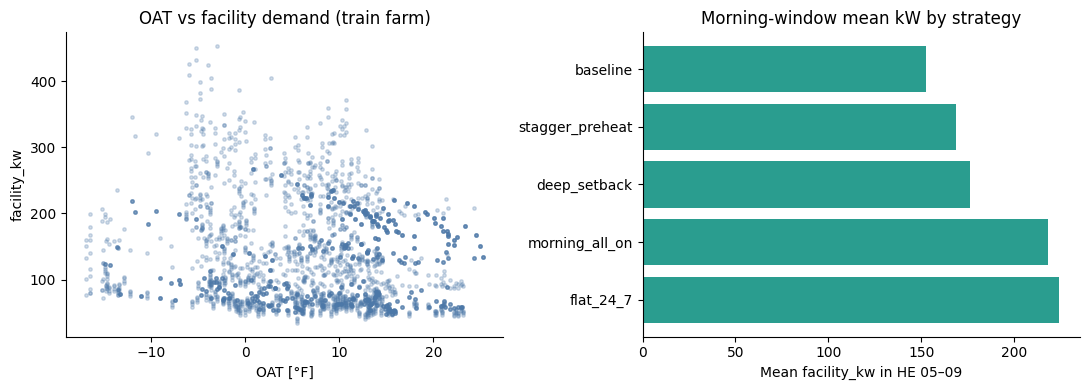

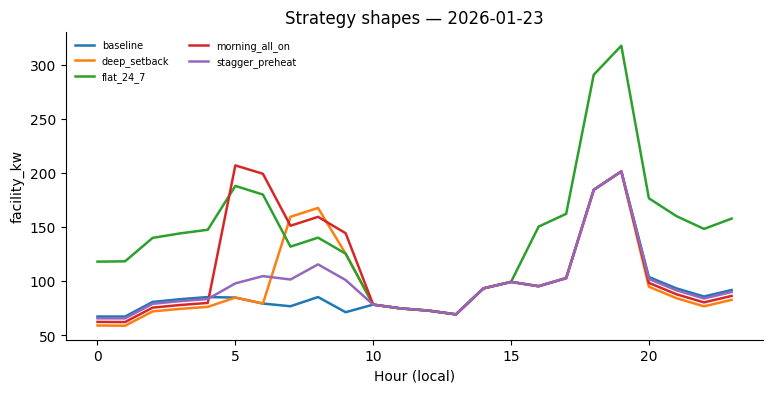

example day 2026-01-23


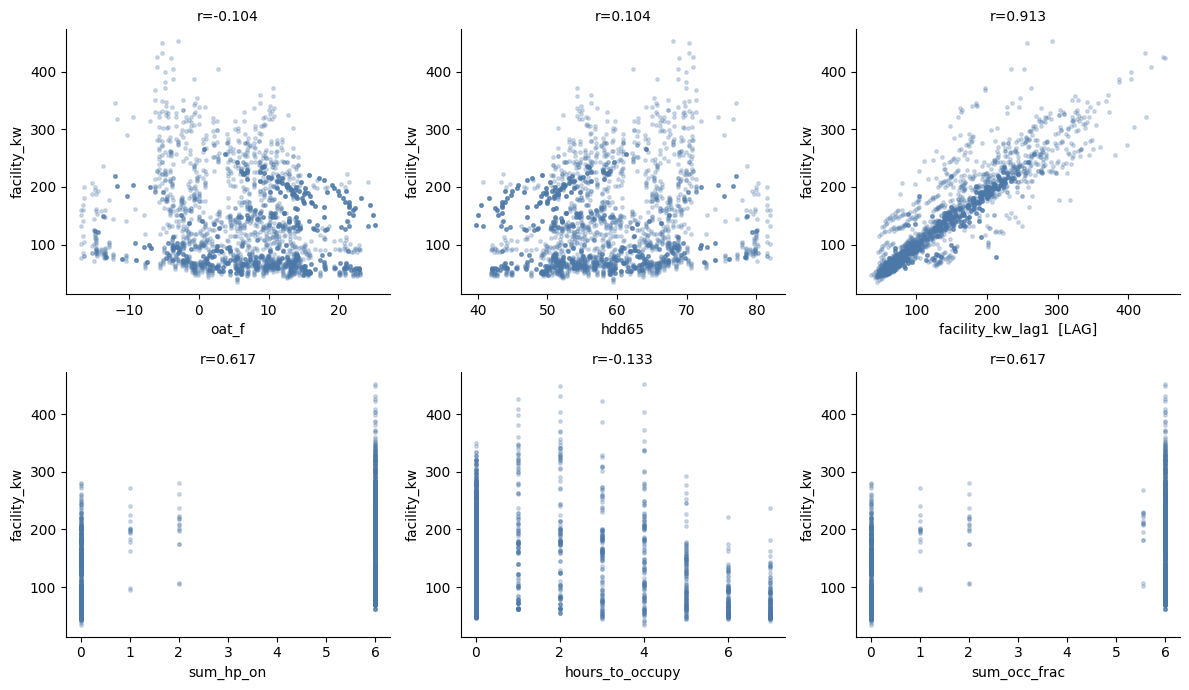

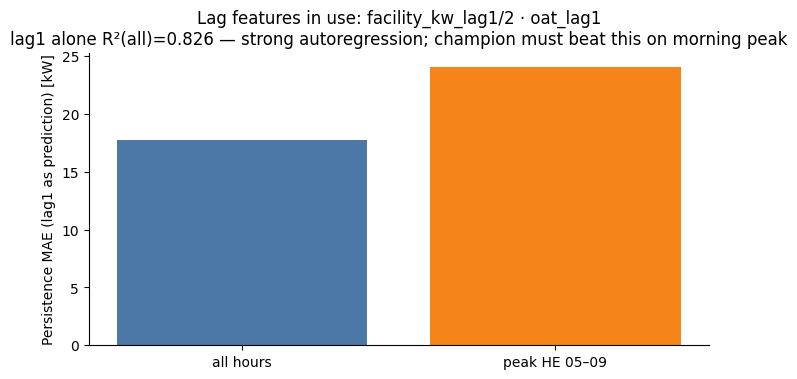

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
oat_vs_kw_scatter(df, ax=axes[0])
strategy_morning_peak_bars(df, ax=axes[1])
plt.tight_layout()
save_fig(PATHS["figures"] / "oat_and_strategy_peak.png", fig)
plt.show()

cold = (
    df[df["is_weekend"] < 0.5]
    .groupby("day")["oat_f"].mean()
    .sort_values()
    .index[0]
)
fig, ax = plt.subplots(figsize=(9, 4))
example_day_profiles(df, cold, ax=ax)
save_fig(PATHS["figures"] / "example_cold_day_strategies.png", fig)
plt.show()
print("example day", cold)

fig = explainer_vs_target_grid(df)
if fig is not None:
    plt.tight_layout()
    save_fig(PATHS["figures"] / "explainer_vs_target.png", fig)
    plt.show()

fig, ax = plt.subplots(figsize=(8, 3.8))
lag_dependence_panel(y, X, cols, peak, ax=ax)
save_fig(PATHS["figures"] / "lag_dependence.png", fig)
plt.show()


## 5 · Model bake-off (GroupKFold) — MAE / RMSE leaderboard

~2× wider RandomizedSearch grids per family (Ridge, ElasticNet, RF, GradientBoosting, ExtraTrees, HGB).
**Desktop ships the bake-off champion** (best morning-peak MAE), exported via skl2onnx.


In [ ]:
result = bake_off(df, n_splits=4, n_iter=40, n_iter_extra_trees=80)
lb = leaderboard_table(result["leaderboard"], result["cv"]["persistence"])
display(lb)
print("CHAMPION (desktop ship):", result["champion"])
print("  display:", DISPLAY_NAMES.get(result["champion"], result["champion"]))
print("  beat persistence:", result["beat_persistence_peak"])
print("  best_params:", result.get("best_params"))
print("  peak MAE:", result["cv"][result["champion"]]["mae_peak_05_09"])
print("  search iters:", result.get("search_iters"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
family_cv_mae_bars(result["leaderboard"], result["cv"]["persistence"]["mae_peak_05_09"], ax=axes[0])
family_mae_rmse_grouped(result["leaderboard"], result["cv"]["persistence"], ax=axes[1])
plt.tight_layout()
save_fig(PATHS["figures"] / "sklearn_leaderboard.png", fig)
plt.show()


## 6 · Champion OOF scorecard — pred vs actual, residuals, importances

Competition-style **MAE / RMSE / R²** on all hours and peak HE 05–09.


,split,model,mae,rmse,r2,n
0,all_hours,extra_trees,13.497806,21.082306,0.918483,2880
1,peak_HE_05_09,extra_trees,17.868297,25.576522,0.919845,600
2,all_hours,persistence_lag1,17.758101,30.821747,0.825769,2880
3,peak_HE_05_09,persistence_lag1,24.086779,39.812850,0.805780,600


Lift vs lag1 on peak MAE: 6.218482005975584 kW


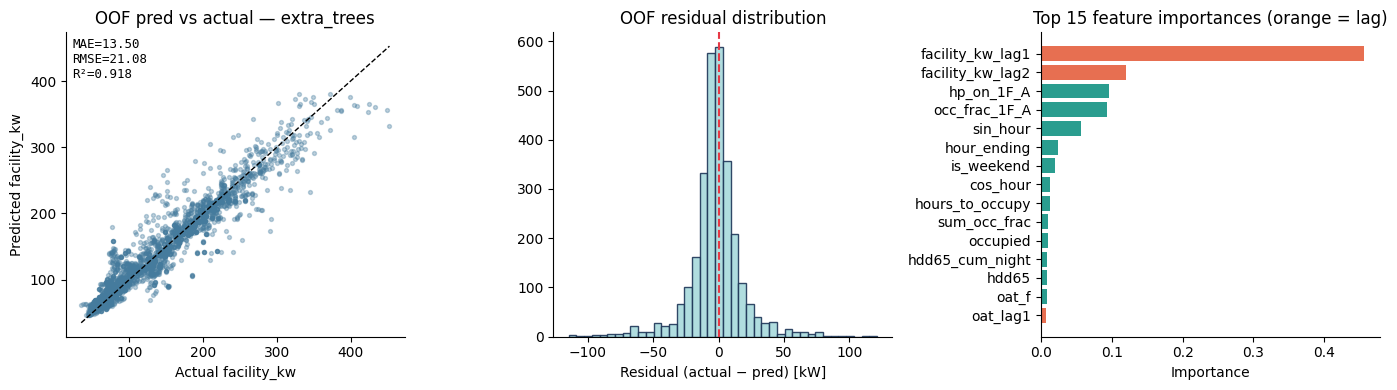

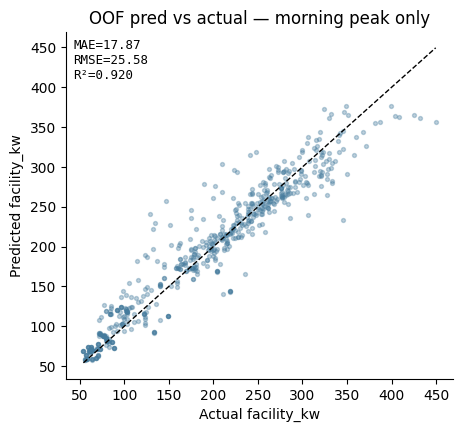

In [16]:
model = result["model"]
oof = np.zeros_like(y)
gkf = GroupKFold(n_splits=result["n_splits"])
for tr, te in gkf.split(X, y, groups):
    m = clone(model)
    m.fit(X[tr], y[tr])
    oof[te] = m.predict(X[te])

# persistence baseline for scorecard
lag_i = cols.index("facility_kw_lag1")
persist = X[:, lag_i]

score = pd.concat(
    [
        metrics_scorecard(y, oof, peak, label=result["champion"]),
        metrics_scorecard(y, persist, peak, label="persistence_lag1"),
    ],
    ignore_index=True,
)
display(score)
print(
    "Lift vs lag1 on peak MAE:",
    float(score.loc[(score.model == "persistence_lag1") & (score.split == "peak_HE_05_09"), "mae"].iloc[0]
          - score.loc[(score.model == result["champion"]) & (score.split == "peak_HE_05_09"), "mae"].iloc[0]),
    "kW",
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pred_vs_actual(y, oof, ax=axes[0], title=f"OOF pred vs actual — {result['champion']}")
residual_hist(y, oof, ax=axes[1])
feature_importance_bar(model, cols, top_n=15, ax=axes[2])
plt.tight_layout()
save_fig(PATHS["figures"] / "oof_parity_resid_importance.png", fig)
plt.show()

# Peak-only parity
fig, ax = plt.subplots(figsize=(5, 4.5))
pred_vs_actual(y[peak], oof[peak], ax=ax, title="OOF pred vs actual — morning peak only")
save_fig(PATHS["figures"] / "oof_parity_peak.png", fig)
plt.show()


## 7 · Cost playground (bill-rate placeholders)

Same formula as Rust desktop: \(c_e \sum kWh + c_d \cdot peak\,kW\).


,energy_kwh,peak_kw,energy_cost,demand_cost,total_cost,annual_total_stub
strategy_id,,,,,,
baseline,2235.295663,201.500000,268.235480,3022.500000,3290.735480,60411.193159
stagger_preheat,2339.453097,201.500000,280.734372,3022.500000,3303.234372,61536.093453
flat_24_7,3484.962925,304.316513,418.195551,4564.747698,4982.943249,92414.571969
morning_all_on,2637.426068,201.502837,316.491128,3022.542549,3339.033677,64754.712127


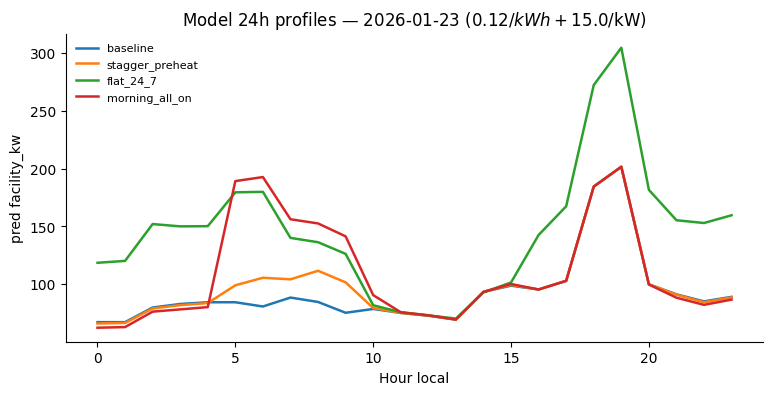

In [17]:
demo_day = cold
rates = {
    "energy_rate_per_kwh": 0.12,
    "demand_rate_per_kw": 15.0,
    "similar_days_per_year": 90.0,
}

rows = []
for sid in ["baseline", "stagger_preheat", "flat_24_7", "morning_all_on"]:
    sub = df[(df["day"] == demo_day) & (df["strategy_id"] == sid)].sort_values("hour_ending")
    Xd, yd, _, _ = matrix_xy(sub)
    pred = model.predict(Xd)
    cost = cost_from_hourly_kw(pred, **rates)
    cost["strategy_id"] = sid
    cost["true_peak"] = float(sub["facility_kw"].max())
    rows.append(cost)

cost_df = pd.DataFrame(rows).set_index("strategy_id")
display(cost_df[["energy_kwh", "peak_kw", "energy_cost", "demand_cost", "total_cost", "annual_total_stub"]])

fig, ax = plt.subplots(figsize=(9, 4))
for sid in cost_df.index:
    sub = df[(df["day"] == demo_day) & (df["strategy_id"] == sid)].sort_values("hour_ending")
    Xd, _, _, _ = matrix_xy(sub)
    ax.plot(sub["hour_ending"], model.predict(Xd), label=sid, lw=1.8)
ce, cd = rates["energy_rate_per_kwh"], rates["demand_rate_per_kw"]
ax.set_title(f"Model 24h profiles — {demo_day} (${ce}/kWh + ${cd}/kW)")
ax.set_xlabel("Hour local")
ax.set_ylabel("pred facility_kw")
ax.legend(fontsize=8, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
save_fig(PATHS["figures"] / "forecast_day_cost_profiles.png", fig)
plt.show()


## 8 · Ship bake-off champion → desktop ONNX + TL;DR

Exports **whatever family won** the peak-MAE bake-off to:

- heating_dsm_hourly_v1.onnx + _feature_meta.json (name, params, MAE/RMSE, ±)
- joblib bundle + champion_summary.json
- copy → desktop/artifacts/ for cargo run --release

If skl2onnx cannot convert the winner, the next-best convertible family is shipped (noted in meta).


In [ ]:
PATHS["joblib"].parent.mkdir(parents=True, exist_ok=True)

champ = result["champion"]
joblib.dump(
    {
        "model": result["model"],
        "tuned_models": result["tuned_models"],
        "feature_cols": result["feature_cols"],
        "champion": champ,
        "best_params": result.get("best_params"),
        "best_params_by_family": result["best_params_by_family"],
        "schema": "lakeside.heating_dsm_hourly.v1",
    },
    PATHS["joblib"],
)

ship = ship_desktop_champion(
    result,
    onnx_path=PATHS["onnx"],
    meta_path=PATHS["feature_meta"],
    training_source=src,
)
summary = {
    "champion": champ,
    "desktop_onnx_family": ship["desktop_family"],
    "model_name": ship["model_name"],
    "best_params": ship["best_params"],
    "desktop_cv": ship["cv"],
    "beat_persistence_peak": result["beat_persistence_peak"],
    "training_source": src,
    "training_parquet": str(pq),
    "oof_scorecard": score.to_dict(orient="records"),
    "cv": result["cv"],
    "onnx_roundtrip_max_abs": ship["roundtrip_max_abs"],
    "fallback_from": ship.get("fallback_from"),
    "leaderboard": [
        {"family": e["family"], "oof_metrics": e["oof_metrics"], "n_iter_searched": e.get("n_iter_searched")}
        for e in result["leaderboard"]
    ],
}
PATHS["champion_summary"].write_text(json.dumps(summary, indent=2, default=str) + "\n", encoding="utf-8")

print("DESKTOP SHIP")
print("  bake-off champion:", champ)
print("  onnx family:", ship["desktop_family"], ship["model_name"])
print("  params:", ship["best_params"])
print("  cv:", ship["cv"])
print("  precision_pm_kw:", ship["meta"].get("precision_pm_kw"))
print("  onnx:", PATHS["onnx"])
print("  copy:", ship["desktop_copy"])
print("  roundtrip_max_abs:", ship["roundtrip_max_abs"])
if ship.get("fallback_from"):
    print("  NOTE: ONNX fallback from", ship["fallback_from"])
print("wrote", PATHS["joblib"])
print("wrote", PATHS["champion_summary"])


## 9 · Multi-target DEMO only (not desktop)

Desktop uses the **single-target bake-off champion** from section 8.
This section is synthetic multi-output analysis only — does not overwrite heating_dsm_hourly_v1.onnx.


In [19]:
# --- DEMO / SYNTHETIC_ZONE_TEMPS knobs (visible for readers) ---
# These are NOT calibrated to Lakeside; they invent IdealLoads-ish recovery labels.
MIDNIGHT_ZONE_F = 62.0
OCC_SP_F = 68.0
UNOCC_SP_F = 60.0
UA_PROXY = 0.03          # envelope sink toward OAT/unocc blend
HP_GAIN = 3.2            # °F toward SP per hour when HP on
SOLAR_GAIN = 0.004
INTERNAL_GAIN = 0.35
NOISE_STD = 0.15
SYNTH_SEED = 21

from synthetic_zone_temps import attach_synthetic_zone_temps, DEFAULT_DEMO_KNOBS
from feature_compile_heating_dsm import (
    TARGET_COLS, FEATURE_COLS_MULTITARGET, ZONE_TEMP_COLS, matrix_xy_multi, morning_peak_mask,
)
from notebook_plots import (
    multitarget_mae_rmse_bars, walk_24h_kw_and_temps, warm_by_start_table,
)
from walk_24h_multitarget import walk_24h_multitarget, default_strategy_hp_grid
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

assert DEFAULT_DEMO_KNOBS  # imported for documentation parity
print("DEMO knobs", dict(
    MIDNIGHT_ZONE_F=MIDNIGHT_ZONE_F, OCC_SP_F=OCC_SP_F, UNOCC_SP_F=UNOCC_SP_F,
    UA_PROXY=UA_PROXY, HP_GAIN=HP_GAIN, SYNTH_SEED=SYNTH_SEED,
))


ImportError: cannot import name 'ZONE_TEMP_COLS' from 'feature_compile_heating_dsm' (C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\feature_compile_heating_dsm.py)

In [ ]:
df_mt = attach_synthetic_zone_temps(
    df,
    midnight_zone_f=MIDNIGHT_ZONE_F,
    occ_sp_f=OCC_SP_F,
    unocc_sp_f=UNOCC_SP_F,
    ua_proxy=UA_PROXY,
    hp_gain=HP_GAIN,
    solar_gain=SOLAR_GAIN,
    internal_gain=INTERNAL_GAIN,
    noise_std=NOISE_STD,
    seed=SYNTH_SEED,
)
print(df_mt["zone_temp_provenance"].iloc[0], "|", df_mt["zone_temp_honesty"].iloc[0][:70], "...")
display(df_mt[ZONE_TEMP_COLS].describe().round(2))


## 10 · Multi-target catalog + GroupKFold scorecard

`FEATURE_COLS_MULTITARGET` = single-target features + `zone_temp_*_f_lag1`.
Targets: `TARGET_COLS` = `facility_kw` + 6 zone temps.


In [ ]:
feat_cat_mt, tgt_cat_mt = feature_target_catalogs(multitarget=True)
print(f"{len(feat_cat_mt)} explainers · {len(tgt_cat_mt)} targets")
display(tgt_cat_mt)
display(feat_cat_mt[feat_cat_mt["role"].astype(str).str.contains("LAG|zone", case=False, na=False)].head(20))

X_mt, Y_mt, groups_mt, feat_cols_mt, tgt_cols_mt = matrix_xy_multi(df_mt)
peak_mt = morning_peak_mask(df_mt)
print("X", X_mt.shape, "Y", Y_mt.shape)


In [ ]:
gkf_mt = GroupKFold(n_splits=min(4, max(2, df_mt["day"].nunique())))
oof_mt = np.zeros_like(Y_mt)
for tr, te in gkf_mt.split(X_mt, Y_mt, groups_mt):
    est = MultiOutputRegressor(
        ExtraTreesRegressor(
            n_estimators=120, max_depth=14, min_samples_leaf=2,
            n_jobs=-1, random_state=21,
        )
    )
    est.fit(X_mt[tr], Y_mt[tr])
    oof_mt[te] = est.predict(X_mt[te])

per_target = {}
for j, name in enumerate(tgt_cols_mt):
    yt, yp = Y_mt[:, j], oof_mt[:, j]
    per_target[name] = {
        "mae": float(mean_absolute_error(yt, yp)),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "r2": float(r2_score(yt, yp)),
    }
# peak-window on facility_kw only
pm = peak_mt
per_target["facility_kw_peak_05_09"] = {
    "mae": float(mean_absolute_error(Y_mt[pm, 0], oof_mt[pm, 0])),
    "rmse": float(np.sqrt(mean_squared_error(Y_mt[pm, 0], oof_mt[pm, 0]))),
    "r2": float(r2_score(Y_mt[pm, 0], oof_mt[pm, 0])),
}
score_mt = pd.DataFrame(per_target).T.round(3)
display(score_mt)

fig, ax = plt.subplots(figsize=(8, 5))
bars = {k: v for k, v in per_target.items() if not k.endswith("peak_05_09")}
multitarget_mae_rmse_bars(bars, ax=ax)
save_fig(PATHS["figures"] / "multitarget_sklearn_mae_rmse.png", fig)
plt.show()


## 11 · Fit multitarget DEMO model + 24h causal forecast sim

Fake 24h OAT defined **in-cell**. Each hour: OAT + strategy/`hp_on_*` + prior kW/temp lags →
joint prediction; carry predictions forward (no future leak).


In [ ]:
mt_model = MultiOutputRegressor(
    ExtraTreesRegressor(
        n_estimators=160, max_depth=14, min_samples_leaf=2,
        n_jobs=-1, random_state=21,
    )
)
mt_model.fit(X_mt, Y_mt)

DEMO_JOBLIB = PATHS["joblib"].parent / "heating_dsm_multitarget_demo.joblib"
joblib.dump(
    {
        "model": mt_model,
        "feature_cols": feat_cols_mt,
        "target_cols": tgt_cols_mt,
        "provenance": "SYNTHETIC_ZONE_TEMPS",
        "honesty": "DEMO multitarget — not production ship path",
        "demo_knobs": dict(
            MIDNIGHT_ZONE_F=MIDNIGHT_ZONE_F, OCC_SP_F=OCC_SP_F, UNOCC_SP_F=UNOCC_SP_F,
            UA_PROXY=UA_PROXY, HP_GAIN=HP_GAIN, SYNTH_SEED=SYNTH_SEED,
        ),
    },
    DEMO_JOBLIB,
)
print("wrote DEMO (does not overwrite v1)", DEMO_JOBLIB)


In [ ]:
# Fake 24h OAT forecast (°F) — DEMO cold weekday
hours = np.arange(24)
OAT_F_24 = 18.0 + 7.0 * np.sin((hours - 4) / 24.0 * 2 * np.pi)  # cold morning dip

STRATEGY_WALK = "stagger_preheat"
hp_grid = default_strategy_hp_grid(STRATEGY_WALK, weekend=False)

def _predict_row(x: np.ndarray) -> np.ndarray:
    return mt_model.predict(x)[0]

walk = walk_24h_multitarget(
    model_predict=_predict_row,
    oat_f_24=OAT_F_24,
    midnight_zone_f=MIDNIGHT_ZONE_F,
    strategy_id=STRATEGY_WALK,
    hp_on_24x6=hp_grid,
    occ_htg_sp_f=OCC_SP_F,
    unocc_htg_sp_f=UNOCC_SP_F,
    facility_kw0=float(df["facility_kw"].median()),
)

rates_walk = {
    "energy_rate_per_kwh": 0.12,
    "demand_rate_per_kw": 15.0,
    "similar_days_per_year": 90.0,
}
cost_walk = cost_from_hourly_kw(walk["facility_kw"], **rates_walk)
print("24h cost stub", {k: round(v, 2) if isinstance(v, float) else v for k, v in cost_walk.items() if k in (
    "energy_kwh", "peak_kw", "energy_cost", "demand_cost", "total_cost"
)})

warm_df = warm_by_start_table(walk, occ_sp_f=OCC_SP_F)
display(warm_df)

fig = walk_24h_kw_and_temps(walk, occ_sp_f=OCC_SP_F)
save_fig(PATHS["figures"] / "walk_24h_sklearn_multitarget.png", fig)
plt.show()


### Multi-target DEMO TL;DR

| | |
|---|---|
| **Desktop model** | ExtraTrees → heating_dsm_hourly_v1.onnx (**kW-only**, section 8) |
| **This section** | Synthetic zone temps + MultiOutput DEMO |
| **Ship?** | No — does not feed Rust until Phase B2 native zone farm |
